**Chapter - 7**

In [3]:
# Import required libraries
import pandas as pd
import numpy as np

# Load the food consumption dataset
food_consumption = pd.read_csv("../Week 8-9/resources/food_consumption.csv")

# Display the first few rows to understand the data
print("First 5 rows of the dataset:")
print(food_consumption.head())
print(f"\nDataset shape: {food_consumption.shape}")
print(f"Columns: {list(food_consumption.columns)}")


First 5 rows of the dataset:
   Unnamed: 0    country food_category  consumption  co2_emission
0           1  Argentina          pork        10.51         37.20
1           2  Argentina       poultry        38.66         41.53
2           3  Argentina          beef        55.48       1712.00
3           4  Argentina     lamb_goat         1.56         54.63
4           5  Argentina          fish         4.36          6.96

Dataset shape: (1430, 5)
Columns: ['Unnamed: 0', 'country', 'food_category', 'consumption', 'co2_emission']


In [4]:
# Instructions #1: Create DataFrames for Belgium and USA
be_consumption = food_consumption[food_consumption['country'] == 'Belgium']
us_consumption = food_consumption[food_consumption['country'] == 'USA']

# Calculate mean and median for Belgium
be_mean = be_consumption['consumption'].mean()
be_median = be_consumption['consumption'].median()

# Calculate mean and median for USA
us_mean = us_consumption['consumption'].mean()
us_median = us_consumption['consumption'].median()

print("Instructions #1 Results:")
print(f"Belgium - Mean: {be_mean:.2f} kg/person/year, Median: {be_median:.2f} kg/person/year")
print(f"USA - Mean: {us_mean:.2f} kg/person/year, Median: {us_median:.2f} kg/person/year")

Instructions #1 Results:
Belgium - Mean: 42.13 kg/person/year, Median: 12.59 kg/person/year
USA - Mean: 44.65 kg/person/year, Median: 14.58 kg/person/year


In [5]:
# Instructions #2: Subset for Belgium and USA, group by country, and calculate using .agg()
be_us_consumption = food_consumption[food_consumption['country'].isin(['Belgium', 'USA'])]

# Group by country and select only the consumption column, then calculate mean and median
consumption_stats = be_us_consumption.groupby('country')['consumption'].agg(['mean', 'median'])

print("\nInstructions #2 Results:")
print(consumption_stats)


Instructions #2 Results:
              mean  median
country                   
Belgium  42.132727   12.59
USA      44.650000   14.58


In [6]:
import matplotlib.pyplot as plt 
rice_consumption = food_consumption[food_consumption['food_category'] == 'rice']
print (rice_consumption.head())

    Unnamed: 0      country food_category  consumption  co2_emission
8            9    Argentina          rice         8.77         11.22
19          20    Australia          rice        11.03         14.12
30          31      Albania          rice         7.78          9.96
41          42      Iceland          rice         3.89          4.98
52          53  New Zealand          rice         9.16         11.72


mean      37.591615
median    15.200000
Name: co2_emission, dtype: float64


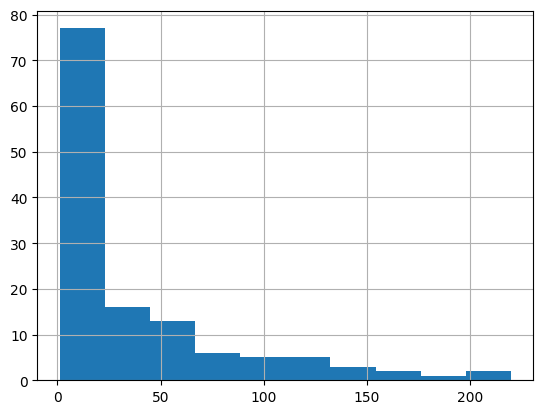

In [7]:
print(rice_consumption['co2_emission'].agg(['mean', 'median']))
rice_consumption['co2_emission'].hist()
plt.show()

In [8]:
# Calculate quartiles of co2_emission (4 quantiles - splits data into 4 pieces)
quartiles = food_consumption['co2_emission'].quantile([0, 0.25, 0.5, 0.75, 1])
print("Quartiles of CO2 emissions (25%, 50%, 75%):")
print(quartiles)
print()

# Calculate quintiles (6 quantiles - splits data into 5 pieces)
quintiles = food_consumption['co2_emission'].quantile([i/5 for i in range(1, 6)])
print("Quintiles of CO2 emissions (20%, 40%, 60%, 80%):")
print(quintiles)
print()

# Calculate deciles (11 quantiles - splits data into 10 pieces)
deciles = food_consumption['co2_emission'].quantile([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])
print("Deciles of CO2 emissions (10%, 20%, 30%, ..., 90%):")
print(deciles)

Quartiles of CO2 emissions (25%, 50%, 75%):
0.00       0.0000
0.25       5.2100
0.50      16.5300
0.75      62.5975
1.00    1712.0000
Name: co2_emission, dtype: float64

Quintiles of CO2 emissions (20%, 40%, 60%, 80%):
0.2       3.540
0.4      11.026
0.6      25.590
0.8      99.978
1.0    1712.000
Name: co2_emission, dtype: float64

Deciles of CO2 emissions (10%, 20%, 30%, ..., 90%):
0.0       0.000
0.1       0.668
0.2       3.540
0.3       7.040
0.4      11.026
0.5      16.530
0.6      25.590
0.7      44.271
0.8      99.978
0.9     203.629
1.0    1712.000
Name: co2_emission, dtype: float64


Variance and Standard Deviation of CO2 emissions by food category:
                        var         std
food_category                          
beef           88748.408132  297.906710
dairy          17671.891985  132.935669
eggs              21.371819    4.622966
fish             921.637349   30.358481
lamb_goat      16475.518363  128.356996
nuts              35.639652    5.969895
pork            3094.963537   55.632396
poultry          245.026801   15.653332
rice            2281.376243   47.763754
soybeans           0.879882    0.938020
wheat             71.023937    8.427570

Histogram of CO2 emissions for beef:


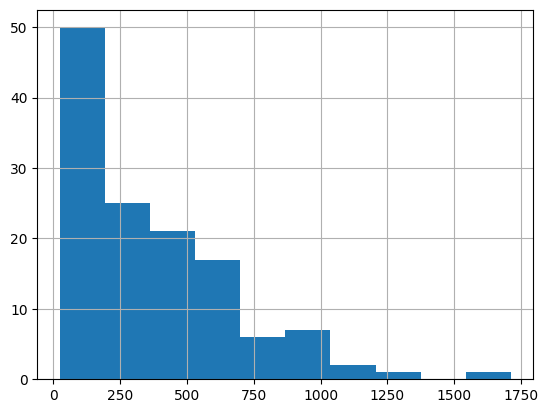


Histogram of CO2 emissions for eggs:


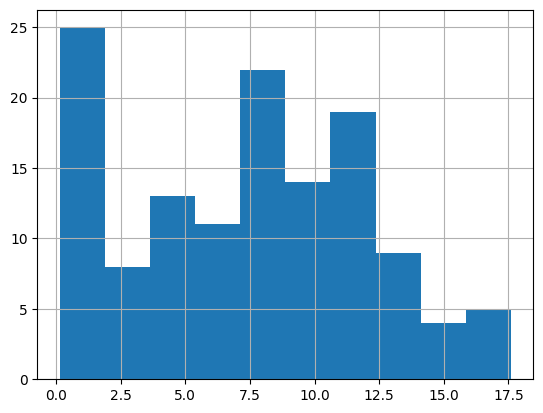

In [9]:
# Calculate variance and standard deviation of co2_emission for each food_category
variance_std = food_consumption.groupby('food_category')['co2_emission'].agg(['var', 'std'])
print("Variance and Standard Deviation of CO2 emissions by food category:")
print(variance_std)
print()

# Create histogram of co2_emission for the beef food_category
beef_co2 = food_consumption[food_consumption['food_category'] == 'beef']['co2_emission']
print("Histogram of CO2 emissions for beef:")
beef_co2.hist()
plt.show()

# Create histogram of co2_emission for the eggs food_category
eggs_co2 = food_consumption[food_consumption['food_category'] == 'eggs']['co2_emission']
print("\nHistogram of CO2 emissions for eggs:")
eggs_co2.hist()
plt.show()

In [10]:
# Compute first and third quartiles of emissions_by_country
emissions_by_country = food_consumption.groupby('country')['co2_emission'].sum()
q1 = emissions_by_country.quantile(0.25)
q3 = emissions_by_country.quantile(0.75)

# Calculate the interquartile range
iqr = q3 - q1

lower = q1 - 1.5 * iqr 
upper = q3 + 1.5 * iqr
print(f"First quartile (25th percentile): {q1}")
print(f"Third quartile (75th percentile): {q3:.2f}")
print(f"Interquartile range: {iqr:.2f}")
print(f"Lower:  {lower:.2f}")
print(f"Upper:  {upper:.2f}")


First quartile (25th percentile): 446.66
Third quartile (75th percentile): 1111.15
Interquartile range: 664.49
Lower:  -550.08
Upper:  2107.89


In [11]:
outliers = emissions_by_country[(emissions_by_country < lower) | (emissions_by_country > upper)]
non_outliers = emissions_by_country[(emissions_by_country >= lower) | (emissions_by_country <= upper)]
print(outliers)

country
Argentina    2172.4
Name: co2_emission, dtype: float64


**Probability**

In [12]:
amir_deals = pd.read_csv("../Week 8-9/resources/amir_deals.csv")
print(amir_deals.head())

   Unnamed: 0    product   client status   amount  num_users
0           1  Product F  Current    Won  7389.52         19
1           2  Product C      New    Won  4493.01         43
2           3  Product B      New    Won  5738.09         87
3           4  Product I  Current    Won  2591.24         83
4           5  Product E  Current    Won  6622.97         17



In [13]:
counts = amir_deals['product'].value_counts()
print(counts)

probability = counts/amir_deals.shape[0]
print(probability)

product
Product B    62
Product D    40
Product A    23
Product C    15
Product F    11
Product H     8
Product I     7
Product E     5
Product N     3
Product G     2
Product J     2
Name: count, dtype: int64
product
Product B    0.348315
Product D    0.224719
Product A    0.129213
Product C    0.084270
Product F    0.061798
Product H    0.044944
Product I    0.039326
Product E    0.028090
Product N    0.016854
Product G    0.011236
Product J    0.011236
Name: count, dtype: float64


In [14]:
np.random.seed(24)
sample_without_replacement = amir_deals.sample(5)
print(sample_without_replacement)
np.random.seed(24)
sample_with_replacement = amir_deals.sample(5, replace = True)
print(sample_with_replacement)

     Unnamed: 0    product   client status   amount  num_users
127         128  Product B  Current    Won  2070.25          7
148         149  Product D  Current    Won  3485.48         52
77           78  Product B  Current    Won  6252.30         27
104         105  Product D  Current    Won  4110.98         39
166         167  Product C      New   Lost  3779.86         11
     Unnamed: 0    product   client status   amount  num_users
162         163  Product D  Current    Won  6755.66         59
131         132  Product B  Current    Won  6872.29         25
87           88  Product C  Current    Won  3579.63          3
145         146  Product A  Current    Won  4682.94         63
145         146  Product A  Current    Won  4682.94         63


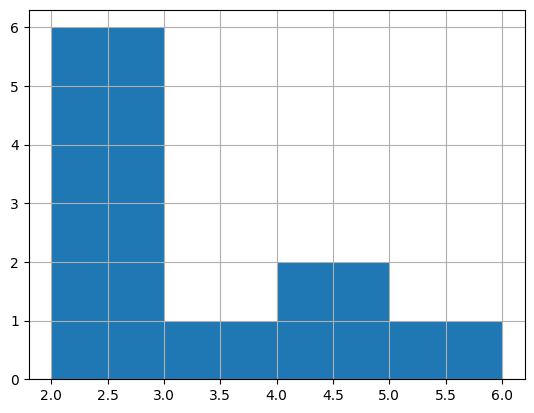

In [15]:
restaurant_groups = pd.read_csv("../Week 8-9/resources/restaurant_groups.csv")
restaurant_groups['group_size'].hist(bins=[2,3,4,5,6])
plt.show()

In [16]:
size_dist = restaurant_groups['group_size'].value_counts()/restaurant_groups.shape[0]
size_dist = size_dist.reset_index()
size_dist.columns = ['group_size', 'prob']
print(size_dist)

   group_size  prob
0           2   0.6
1           4   0.2
2           6   0.1
3           3   0.1



In [17]:
expected_value = np.sum(size_dist['group_size'] * size_dist['prob'])
print(f'The expected value: {expected_value:.2f}')

groups_4_or_more = size_dist[size_dist['group_size']>=4]
prob_4_or_more = np.sum(groups_4_or_more['prob'])
print(f'The probability: {prob_4_or_more:.2f}')

The expected value: 2.90
The probability: 0.30

The probability: 0.30


In [18]:
from scipy.stats import uniform
uniform.cdf(7,0,12)

np.float64(0.5833333333333334)

In [19]:
1 - uniform.cdf(7,0,12)


np.float64(0.41666666666666663)

In [20]:
uniform.cdf(7,0,12) - uniform.cdf(4,0,12)

np.float64(0.25000000000000006)

In [21]:
uniform.rvs(0,5, size = 10)

array([1.1003365 , 1.80528177, 3.69920495, 4.98227863, 1.58173489,
       0.6827229 , 1.91990005, 1.60259642, 1.83207377, 3.54825781])

In [22]:
min_time = 0
max_time = 30
prob_less_than_5 = uniform.cdf(5,0,30)
print(prob_less_than_5)

0.16666666666666666


In [23]:
prob_greater_than_5 = 1-uniform.cdf(5,0,30)
print(prob_greater_than_5)

0.8333333333333334


In [24]:
prob_between_10_and_20 = uniform.cdf(20,0,30) - uniform.cdf(10,0,30)
print(prob_between_10_and_20) 

0.3333333333333333


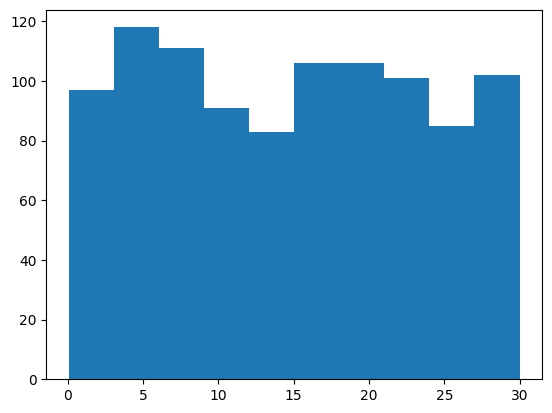

In [25]:
np.random.seed(334)
wait_times =  uniform.rvs(0, 30, size = 1000)
plt.hist(wait_times)
plt.show()

In [26]:
from scipy.stats import norm 
norm.cdf(154,161,7)

np.float64(0.15865525393145707)

In [27]:
1-norm.cdf(154,161,7)

np.float64(0.8413447460685429)

In [28]:
norm.cdf(157,161,7) - norm.cdf(154,161,7)

np.float64(0.1251993291672192)

In [29]:
norm.rvs(161, 7, size = 10)

array([170.38780162, 164.33293628, 156.84955026, 159.30632522,
       150.50084876, 161.69075129, 165.01008514, 158.3003857 ,
       149.21039262, 159.55371326])

In [30]:
die = pd.Series([1,2,3,4,5,6])
samp_5 = die.sample(5, replace = True)
print(samp_5)
np.mean(samp_5)

1    2
5    6
0    1
3    4
3    4
dtype: int64


np.float64(3.4)

In [31]:
sample_means = []
for i in range(10):
    samp_5 = die.sample(5, replace = True)
    sample_means.append(np.mean(samp_5))
print(sample_means)


[np.float64(4.8), np.float64(4.0), np.float64(2.0), np.float64(3.8), np.float64(2.8), np.float64(4.0), np.float64(3.6), np.float64(4.6), np.float64(4.0), np.float64(3.8)]


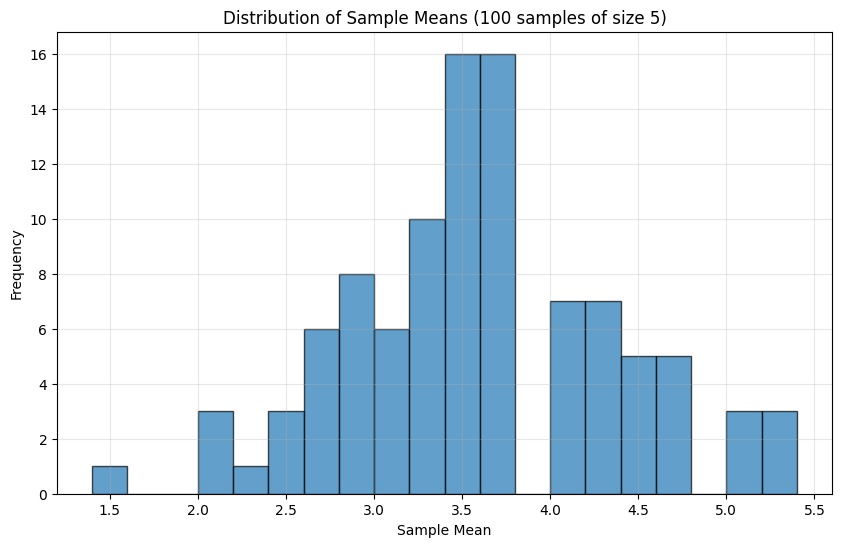

In [32]:
sample_means = []
for i in range(100):
    sample_means.append(np.mean(die.sample(5, replace = True)))
    
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Means (100 samples of size 5)')
plt.grid(True, alpha=0.3)
plt.show()

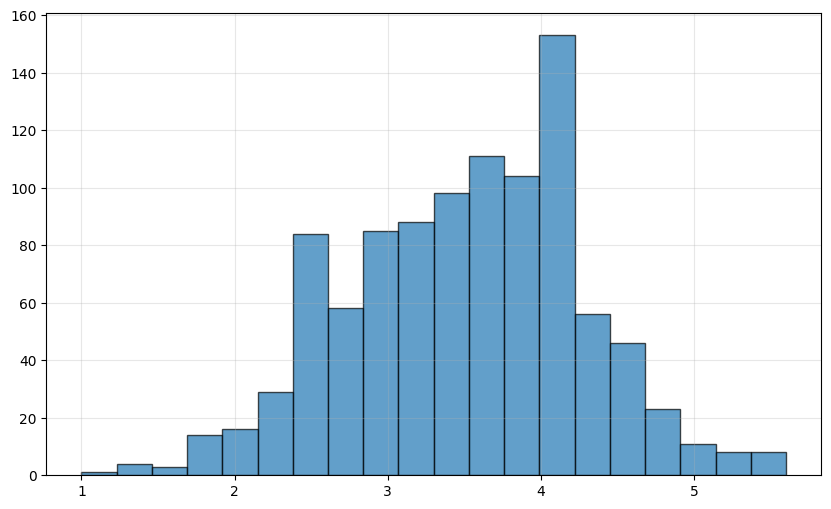

In [33]:
sample_means = []
for i in range(1000):
    sample_means.append(np.mean(die.sample(5, replace = True)))

plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins = 20, edgecolor='black',alpha = 0.7)
plt.grid(True, alpha = 0.3)
plt.show()

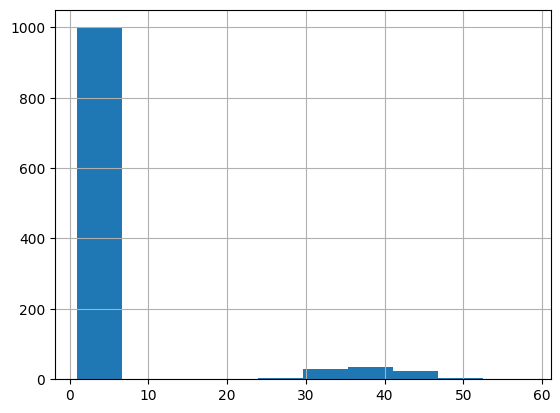

In [34]:
np.random.seed(104)
sample_mean = []
for i in range(100): 
    samp_20 = amir_deals['num_users'].sample(20, replace = True)
    samp_20_mean = np.mean(samp_20)
    sample_means.append(samp_20_mean)

sample_means_series = pd.Series(sample_means)
sample_means_series.hist()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

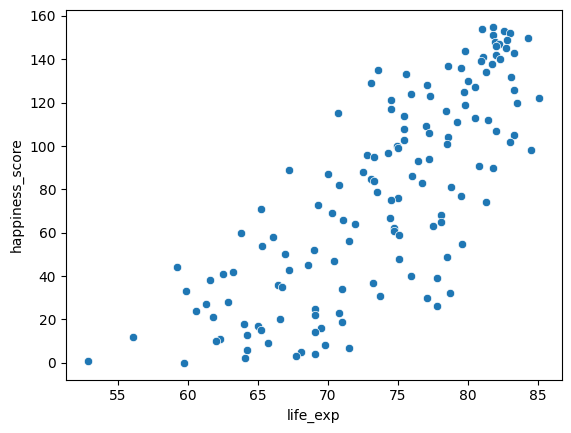

In [35]:
import seaborn as sns
world_happiness = pd.read_csv('../Week 8-9/resources/world_happiness.csv')
sns.scatterplot(x = 'life_exp', y = 'happiness_score', data = world_happiness)
plt.show

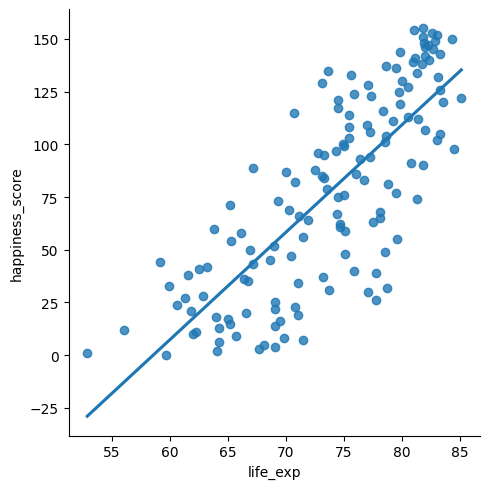

0.7802249053272062


In [36]:
sns.lmplot(x='life_exp', y = 'happiness_score', data = world_happiness, ci = None)
plt.show()
cor = world_happiness['life_exp'].corr(world_happiness['happiness_score'])
print(cor)

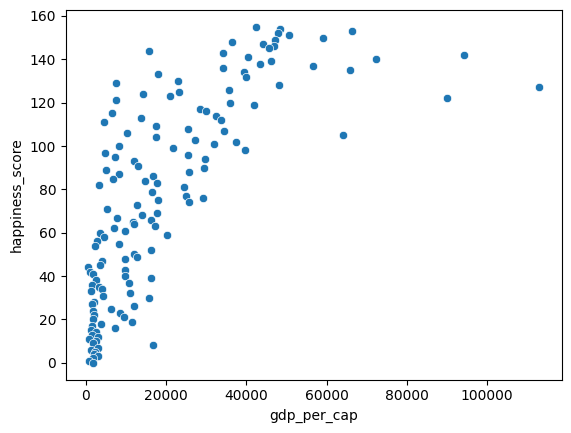

0.7279733012222975


In [37]:
sns.scatterplot(x='gdp_per_cap', y = 'happiness_score', data = world_happiness)
plt.show()
cor = world_happiness['gdp_per_cap'].corr(world_happiness['happiness_score'])
print(cor)

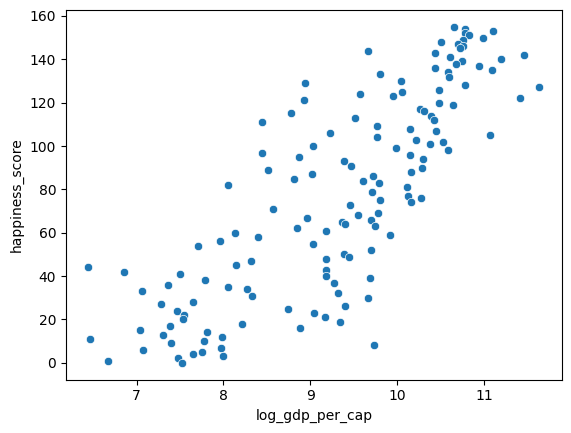

0.8043146004918288


In [38]:
world_happiness['log_gdp_per_cap'] = np.log(world_happiness['gdp_per_cap']) 
sns.scatterplot(x='log_gdp_per_cap', y = 'happiness_score', data = world_happiness)
plt.show()
correlationWH = world_happiness['log_gdp_per_cap'].corr(world_happiness['happiness_score'])
print(correlationWH)